<a href="https://colab.research.google.com/github/sangji90-dotcom/electronic/blob/main/electronic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas scikit-learn xgboost matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [3]:
# 220만 개 데이터를 대신하여 10,000개의 샘플 데이터 생성
np.random.seed(42)
data_size = 10000

data = {
    'temp': np.random.uniform(-10, 35, data_size),      # 기온 (-10도 ~ 35도)
    'humidity': np.random.uniform(20, 90, data_size),  # 상대습도
    'wind': np.random.uniform(0, 15, data_size),      # 풍속
    'year': np.random.choice([2020, 2021, 2022], data_size),
    'hour': np.random.randint(0, 24, data_size)
}

df = pd.DataFrame(data)

# 로직: 전력부하비율에 따른 타겟 생성 (낮음:0, 보통:1, 높음:2)
# 실제로는 기온이 높고 습도가 높을 때 전력 소비가 늘어나는 경향을 반영
df['load_score'] = (df['temp'] * 0.5) + (df['humidity'] * 0.2) + np.random.normal(0, 5, data_size)
df['target'] = pd.qcut(df['load_score'], 3, labels=[0, 1, 2]) # 3등분하여 등급화

# 학습용 데이터 분리
X = df[['temp', 'humidity', 'wind', 'year', 'hour']]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# 1. XGBoost (PPT 최고 성능 모델)
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print(f"XGBoost 정확도: {accuracy_score(y_test, xgb_pred):.2f}")
print(f"Random Forest 정확도: {accuracy_score(y_test, rf_pred):.2f}")

XGBoost 정확도: 0.65
Random Forest 정확도: 0.64


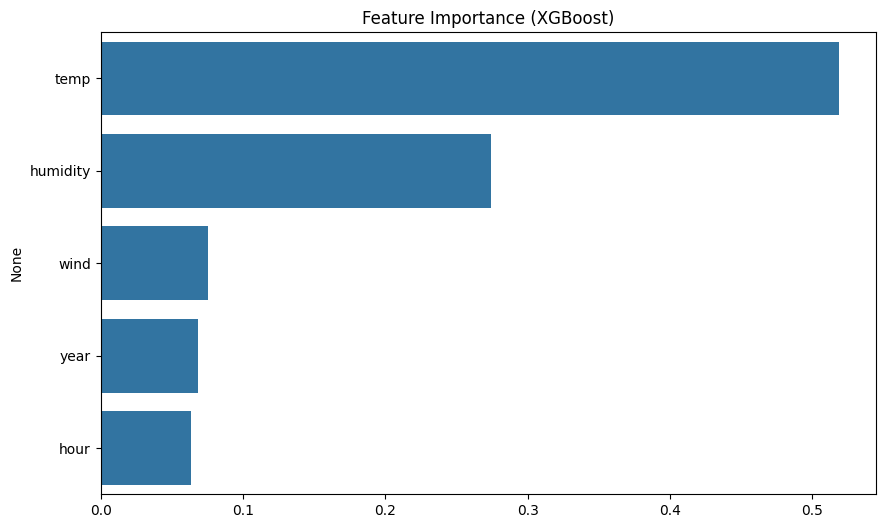

In [5]:
# 피처 중요도 시각화 (어떤 요인이 전력 소비에 영향을 많이 주었나?)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=xgb.feature_importances_, y=X.columns)
plt.title('Feature Importance (XGBoost)')
plt.show()